# Fake News Detection System using Python & ML

In [1]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Step 2: Load and Label Datasets
fake_df = pd.read_csv(r"C:\Users\AMIR\Downloads\my project\Augmented_Fake.csv")
true_df = pd.read_csv(r"C:\Users\AMIR\Downloads\my project\Augmented_True.csv")
fake_df['label'] = 0
true_df['label'] = 1
data_df = pd.concat([fake_df, true_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

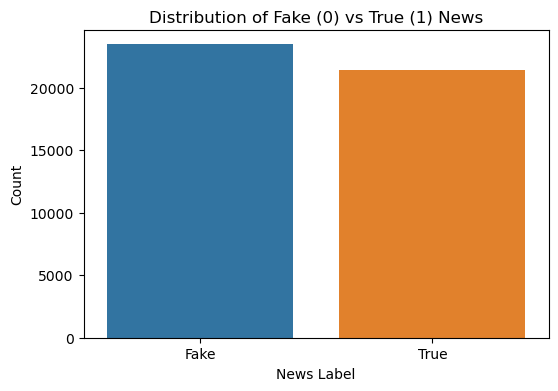

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data_df)
plt.title("Distribution of Fake (0) vs True (1) News")
plt.xlabel("News Label")
plt.ylabel("Count")
plt.xticks([0, 1], ['Fake', 'True'])
plt.show()


In [4]:
# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(data_df['text'], data_df['label'], test_size=0.25, random_state=42)

In [5]:
# Step 4: TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [6]:
# Step 5: Train Model
pac = PassiveAggressiveClassifier(max_iter=1000)
pac.fit(X_train_vec, y_train)

PassiveAggressiveClassifier()

In [7]:
# Step 6: Evaluation
y_pred = pac.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9939426331729913

Confusion Matrix:
 [[5896   45]
 [  23 5262]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      5941
           1       0.99      1.00      0.99      5285

    accuracy                           0.99     11226
   macro avg       0.99      0.99      0.99     11226
weighted avg       0.99      0.99      0.99     11226



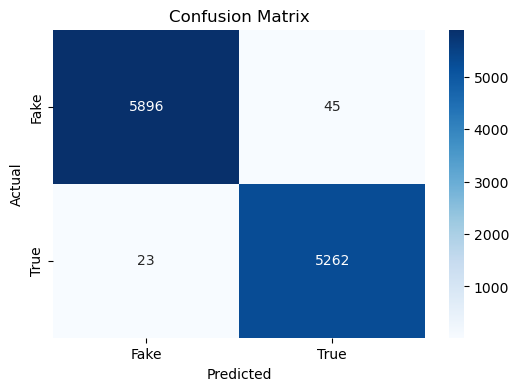

In [8]:
# Predictions and Confusion Matrix
y_pred = pac.predict(X_test_vec)

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# Step 7: Test on Manual Data
manual_test_df = pd.read_csv("manual_testing.csv")
manual_vec = vectorizer.transform(manual_test_df['text'])
manual_predictions = pac.predict(manual_vec)
manual_test_df['predicted_label'] = manual_predictions
manual_test_df['predicted_result'] = manual_test_df['predicted_label'].map({0: 'FAKE', 1: 'REAL'})
manual_test_df[['title', 'predicted_result']].head()

,title,predicted_result
0,Seven Iranians freed in the prisoner swap have...,FAKE
1,#Hashtag Hell & The Fake Left,FAKE
2,Astroturfing: Journalist Reveals Brainwashing ...,FAKE
3,The New American Century: An Era of Fraud,FAKE
4,Hillary Clinton: ‘Israel First’ (and no peace ...,FAKE


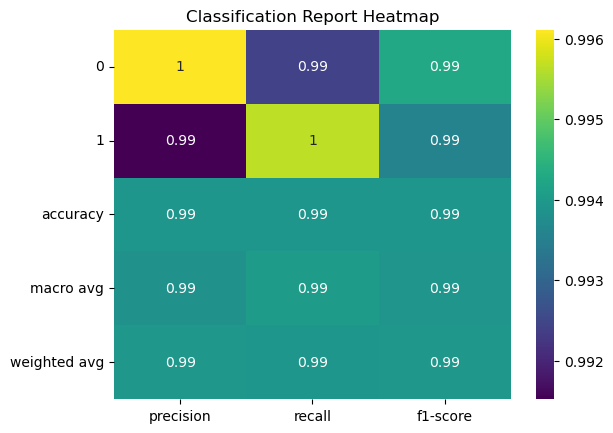

In [10]:
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='viridis')
plt.title("Classification Report Heatmap")
plt.show()

In [ ]:
# Step 8: Predict on Custom Input
custom_input = input("Enter news article text to classify as FAKE or REAL:\n")
custom_vec = vectorizer.transform([custom_input])
prediction = pac.predict(custom_vec)[0]
print("\nPrediction:", "FAKE" if prediction == 0 else "REAL")